# K-Means (Primary Weird Bucket First)

This notebook isolates the most globally isolated vessels first, then clusters the rest.

Two modes:
- **A:** 1 weird bucket first, cluster all remaining into 11 core groups.
- **B:** 1 weird bucket first, optionally split additional weird buckets, then cluster core so total groups = 12.

Use toggles at the top and rerun.

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from cluster_utils import (
    attach_labels,
    build_labels_with_primary_isolated_weird,
    build_weighted_matrix,
    compute_cluster_compactness,
    evaluate_labels,
    export_final_cluster_csvs,
    find_repo_root,
    get_feature_groups,
    load_feature_table,
    stack_cluster_outlines,
)

In [11]:
REPO_ROOT = find_repo_root(Path.cwd())
FEATURE_CSV = REPO_ROOT / "process_data/features/silhouette_features.csv"
REAL_IMAGES_DIR = REPO_ROOT / "process_data/generated/real_images"

# Feature weights
LR_W = 1.0
TB_W = 0.20
SHAPE_W = 1.0
INNER_W = 0.8
INNER_COUNT_W = 0.5

# Grouping strategy toggles
TOTAL_GROUPS = 12
N_WEIRD_BUCKETS = 3      # 1..3
PRIMARY_WEIRD_FRACTION = 0.03   # true isolated bucket size
SECONDARY_WEIRD_FRACTION = 0.07 # next isolated tail for weird #2/#3
PRIMARY_KNN_K = 7

RANDOM_STATE = 42

FEATURE_CSV, REAL_IMAGES_DIR

(PosixPath('/Users/oliviakasmin/Desktop/okasmin-parsons-thesis-2026/process_data/features/silhouette_features.csv'),
 PosixPath('/Users/oliviakasmin/Desktop/okasmin-parsons-thesis-2026/process_data/generated/real_images'))

In [12]:
def plot_cluster_sizes(df_labeled: pd.DataFrame):
    counts = df_labeled["cluster"].value_counts().sort_index()
    plt.figure(figsize=(10, 4))
    counts.plot(kind="bar")
    plt.title("Cluster Size Distribution")
    plt.xlabel("cluster")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


def plot_pca_projection(X: np.ndarray, labels: np.ndarray, title: str):
    pca = PCA(n_components=2, random_state=42)
    points = pca.fit_transform(X)
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(points[:, 0], points[:, 1], c=labels, s=10, cmap="tab20", alpha=0.85)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(sc, label="cluster")
    plt.tight_layout()
    plt.show()

Run details:
{'total_groups': 12, 'n_weird_buckets': 3, 'n_core_clusters': 9, 'primary_weird_fraction': 0.03, 'secondary_weird_fraction': 0.07, 'primary_weird_count': 117, 'secondary_weird_count': 272, 'core_count': 3499, 'primary_knn_k': 7}
Metrics:
{'n_rows': 3888, 'n_features': 297, 'n_clusters': 12, 'silhouette': 0.11044143467695325, 'calinski_harabasz': 441.44287937061404, 'davies_bouldin': 3.379448847926455}


,cluster,size,mean_dist_to_centroid,median_dist_to_centroid,p90_dist_to_centroid
10,10,467,4.585751,4.249296,6.513153
9,9,551,6.028947,5.469469,8.875317
8,8,411,6.496732,5.746826,9.577965
4,4,525,6.536822,5.924545,9.847102
3,3,475,7.061922,6.718754,10.421834
6,6,317,7.143712,6.790089,10.371404
7,7,373,7.631975,7.369851,10.055503
5,5,256,8.274299,7.870053,11.287323
11,11,124,10.329120,10.198456,12.280412
2,2,108,14.780430,14.584826,18.202959


cluster
0     117
1     164
2     108
3     475
4     525
5     256
6     317
7     373
8     411
9     551
10    467
11    124
Name: count, dtype: int64


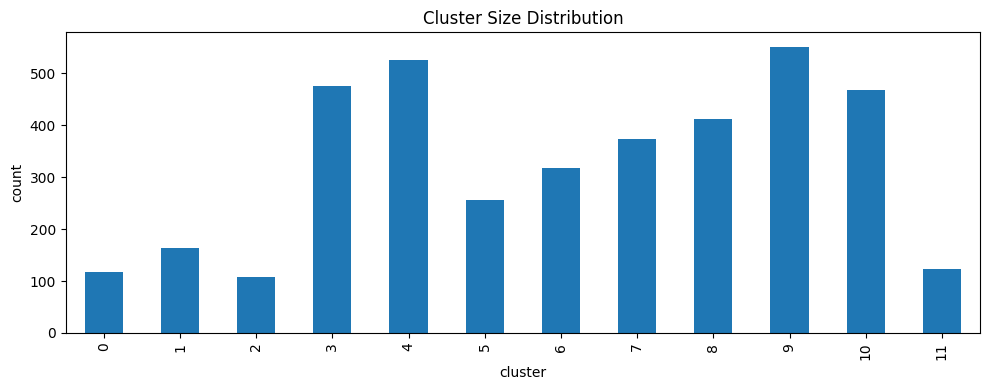

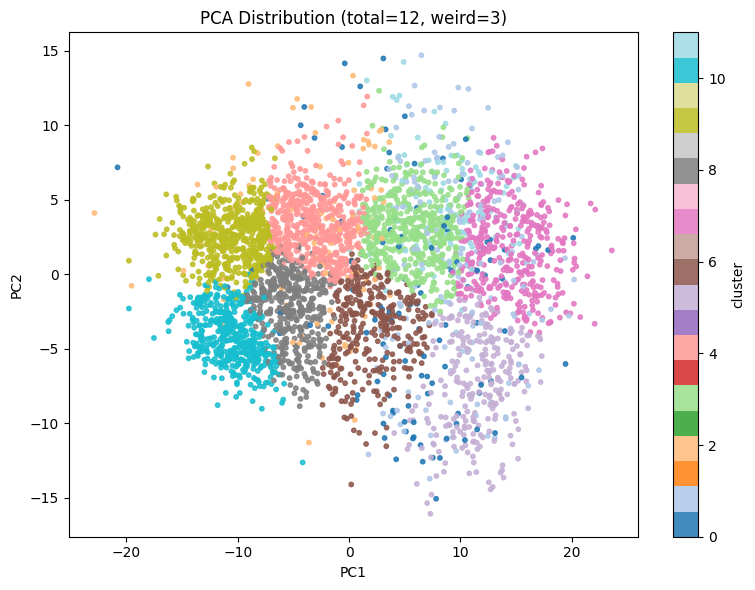

In [13]:
# ---- Main run ----

df = load_feature_table(FEATURE_CSV)
groups = get_feature_groups(df)
X, used_cols, imputer, scaler, W = build_weighted_matrix(
    df,
    groups,
    lr_weight=LR_W,
    tb_weight=TB_W,
    shape_weight=SHAPE_W,
    inner_weight=INNER_W,
    inner_count_weight=INNER_COUNT_W,
)

final_labels, details = build_labels_with_primary_isolated_weird(
    X,
    total_groups=TOTAL_GROUPS,
    n_weird_buckets=N_WEIRD_BUCKETS,
    primary_weird_fraction=PRIMARY_WEIRD_FRACTION,
    secondary_weird_fraction=SECONDARY_WEIRD_FRACTION,
    random_state=RANDOM_STATE,
    primary_knn_k=PRIMARY_KNN_K,
)

df_labeled = attach_labels(df, final_labels)
metrics = evaluate_labels(X, final_labels)
compactness = compute_cluster_compactness(X, final_labels)

print("Run details:")
print({k: v for k, v in details.items() if k != "isolation_score"})
print("Metrics:")
print(metrics)

display(compactness)
print(df_labeled["cluster"].value_counts().sort_index())

plot_cluster_sizes(df_labeled)
plot_pca_projection(
    X,
    final_labels,
    title=f"PCA Distribution (total={TOTAL_GROUPS}, weird={N_WEIRD_BUCKETS})",
)

cluster=0 (weird), n=117


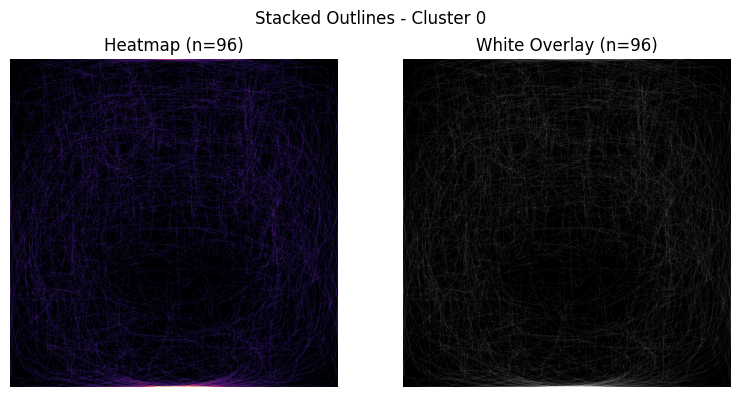

['185901', '187701', '188645', '188900', '188993', '191731', '194262', '194439', '194471', '195766', '195775', '197532', '197570', '199601', '201359', '201394', '201738', '203304', '203363', '203401', '204066', '204071', '205929', '205930', '205935', '205979', '206392', '206507', '207153', '207189']
cluster=1 (weird), n=164


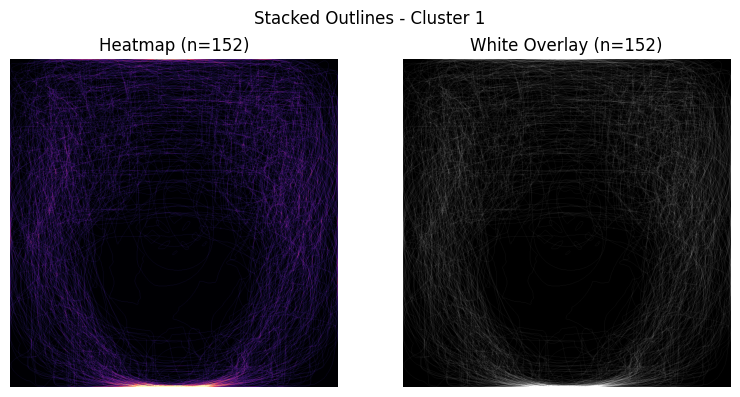

['187863', '192014', '194307', '194591', '195127', '196568', '198416', '199261', '199271', '199285', '199338', '199372', '199730', '200917', '201730', '201732', '201781', '202191', '203282', '204026', '204046', '204047', '204058', '204062', '204072', '204350', '204354', '204380', '204382', '204383']
cluster=2 (weird), n=108


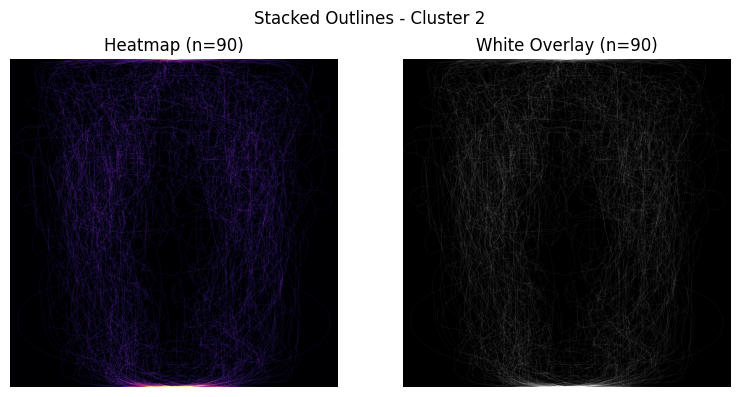

['187805', '191142', '192830', '194230', '194243', '194279', '194395', '194967', '195041', '195272', '195302', '195780', '196343', '196553', '197485', '197580', '197819', '199569', '200861', '200868', '200869', '200944', '200982', '201610', '201695', '201762', '202124', '202171', '202192', '203083']
cluster=3 (core), n=475


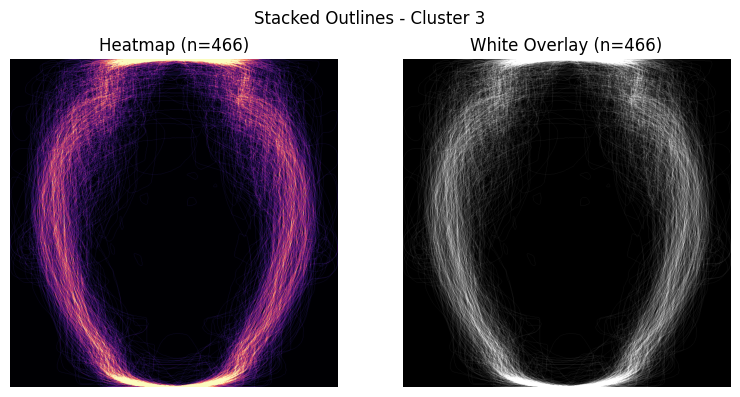

['185900', '185902', '187733', '187791', '187828', '187829', '187854', '187871', '188533', '188534', '188535', '188974', '188976', '188998', '190648', '191583', '192803', '193020', '193109', '194287', '194391', '194433', '194963', '195277', '195499', '195741', '195742', '196544', '196601', '197224']
cluster=4 (core), n=525


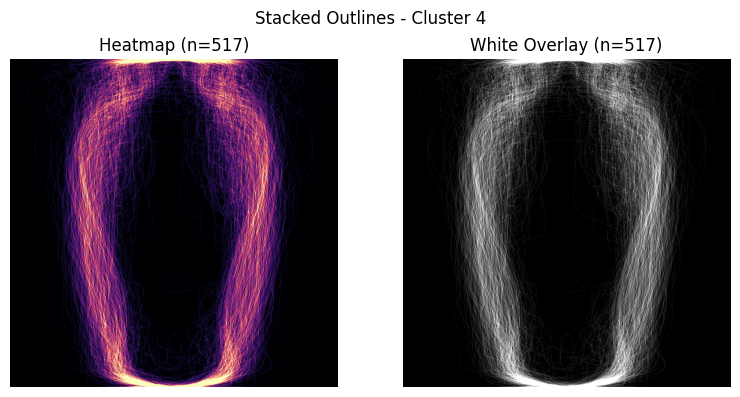

['186687', '187702', '187750', '187794', '187857', '187860', '188541', '188563', '188633', '188753', '190547', '190649', '190657', '191344', '191733', '191779', '193084', '194261', '194301', '194303', '194380', '194383', '194390', '194392', '194472', '194479', '194586', '194608', '194960', '194961']
cluster=5 (core), n=256


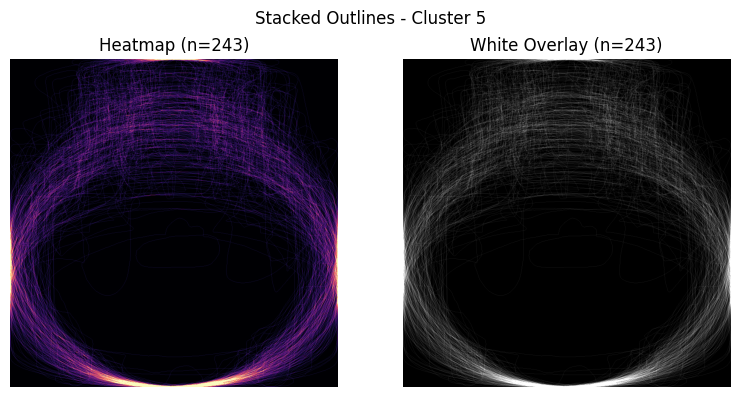

['192949', '199021', '200734', '200841', '201250', '201881', '202205', '206328', '207477', '208009', '208439', '208459', '307619', '307620', '307622', '307865', '307866', '308291', '308292', '308293', '308294', '308296', '308297', '308300', '308303', '308350', '308355', '308359', '308379', '308380']
cluster=6 (core), n=317


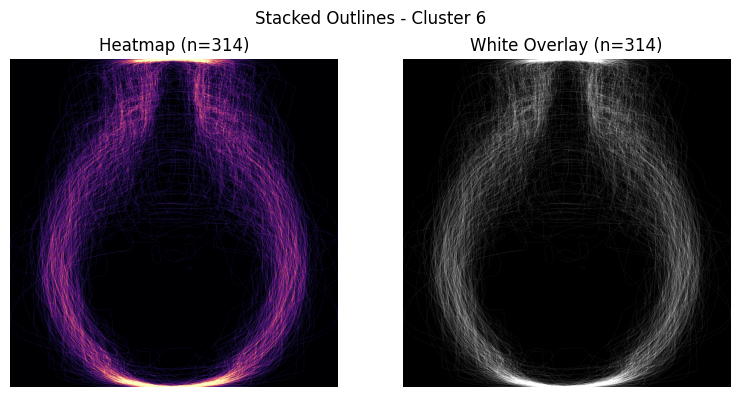

['190647', '192034', '192308', '194291', '194304', '194475', '194590', '195217', '197605', '197612', '197993', '198963', '199110', '199111', '199534', '200823', '200921', '201054', '202243', '203299', '206385', '207775', '207776', '207983', '208389', '208409', '208556', '208806', '209254', '210743']
cluster=7 (core), n=373


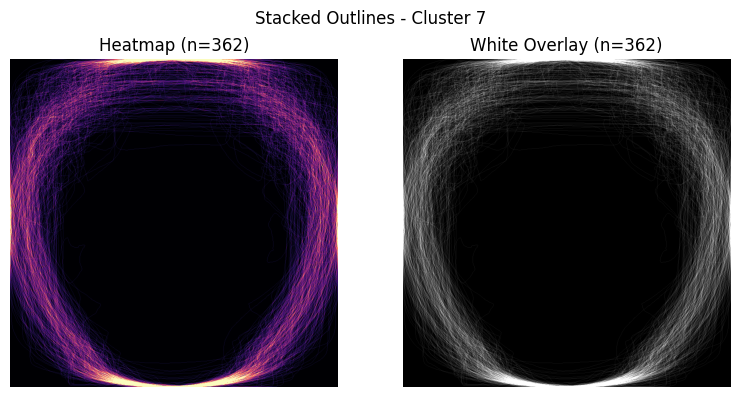

['188556', '195208', '195209', '198433', '198780', '198781', '199343', '199470', '199740', '200839', '200840', '200875', '200876', '201290', '201756', '202967', '203266', '207815', '208121', '208122', '208248', '208403', '208554', '308348', '308420', '308492', '308531', '308577', '308578', '308590']
cluster=8 (core), n=411


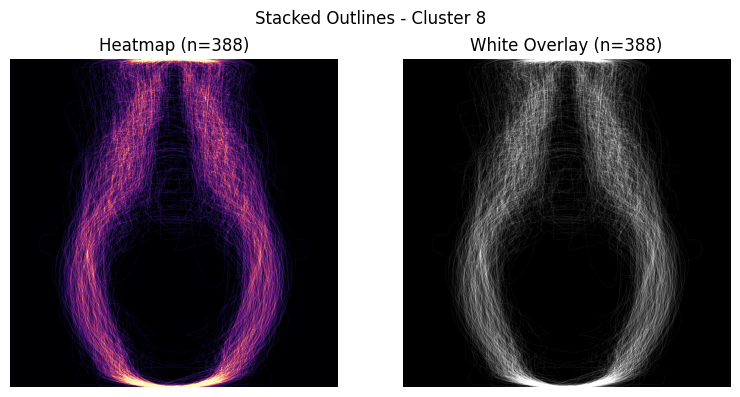

['187746', '187748', '187749', '188765', '188972', '190600', '190797', '191593', '194232', '194239', '194288', '194432', '194582', '194583', '194587', '194588', '194589', '197232', '198321', '198322', '198677', '198707', '198972', '199273', '199334', '199335', '199337', '199542', '199579', '200726']
cluster=9 (core), n=551


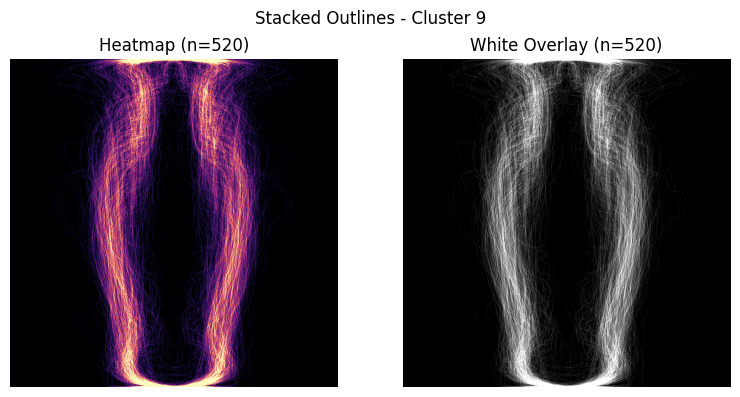

['187660', '187801', '187856', '187858', '187859', '188536', '188537', '188538', '188539', '188777', '190474', '191206', '191218', '191375', '191600', '191636', '191778', '192801', '192810', '192811', '192831', '192844', '192854', '193449', '194229', '194231', '194233', '194234', '194235', '194236']
cluster=10 (core), n=467


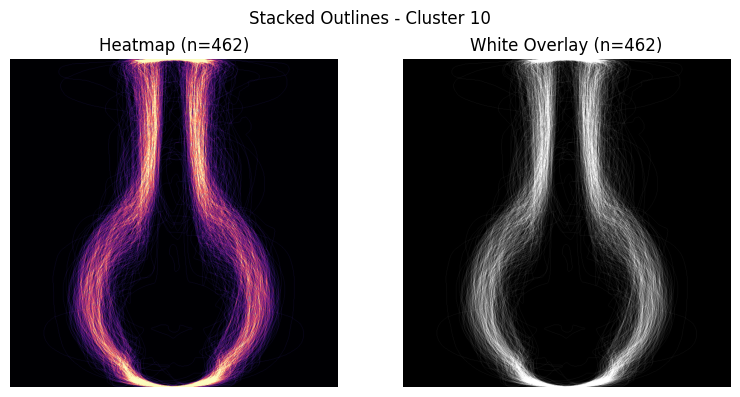

['190732', '191213', '192800', '192802', '194228', '195500', '195501', '196359', '196360', '196361', '196567', '197233', '197515', '197829', '199348', '199461', '199466', '199559', '199582', '200891', '201031', '201032', '201752', '203192', '203257', '204090', '205328', '205335', '205922', '206024']
cluster=11 (core), n=124


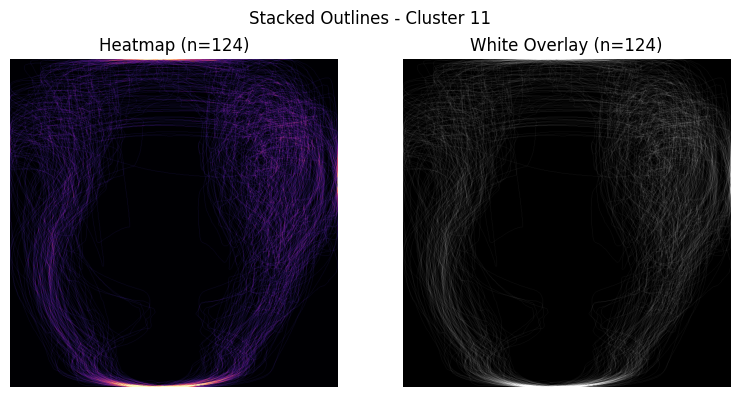

['185914', '186684', '188908', '188994', '191780', '193062', '193063', '193064', '193077', '193093', '193355', '194292', '194488', '194624', '194632', '194636', '194637', '194639', '194644', '194906', '195307', '197552', '197572', '197614', '197616', '198409', '198426', '198432', '198575', '198669']


In [14]:
# ---- Overlay inspection (weird buckets first) ----
weird_labels = list(range(N_WEIRD_BUCKETS))
core_labels = [c for c in sorted(df_labeled["cluster"].unique().tolist()) if c not in weird_labels]
ordered_labels = weird_labels + core_labels

for cluster_id in ordered_labels:
    kind = "weird" if cluster_id in weird_labels else "core"
    n_cluster = len(df_labeled[df_labeled["cluster"] == cluster_id])
    print("=" * 80)
    print(f"cluster={cluster_id} ({kind}), n={n_cluster}")

    _ = stack_cluster_outlines(
        df_labeled,
        cluster_id=cluster_id,
        real_images_dir=REAL_IMAGES_DIR,
        max_images=None,
        alpha_per_image=0.08,
    )

    sample_ids = (
        df_labeled.loc[df_labeled["cluster"] == cluster_id, "object_id"]
        .astype(str)
        .head(30)
        .tolist()
    )
    print(sample_ids)

In [15]:
# ---- Sweep weird-bucket count while keeping total groups fixed ----

rows = []
for weird_n in [1, 2, 3]:
    labels_s, details_s = build_labels_with_primary_isolated_weird(
        X,
        total_groups=12,
        n_weird_buckets=weird_n,
        primary_weird_fraction=PRIMARY_WEIRD_FRACTION,
        secondary_weird_fraction=SECONDARY_WEIRD_FRACTION,
        random_state=RANDOM_STATE,
        primary_knn_k=PRIMARY_KNN_K,
    )
    metrics_s = evaluate_labels(X, labels_s)
    compact_s = compute_cluster_compactness(X, labels_s)
    top8_mean_dist = float(compact_s.head(8)["mean_dist_to_centroid"].mean()) if len(compact_s) >= 8 else np.nan

    rows.append(
        {
            "weird_buckets": weird_n,
            "core_clusters": 12 - weird_n,
            "primary_weird_count": details_s["primary_weird_count"],
            "secondary_weird_count": details_s["secondary_weird_count"],
            "silhouette": metrics_s["silhouette"],
            "calinski_harabasz": metrics_s["calinski_harabasz"],
            "davies_bouldin": metrics_s["davies_bouldin"],
            "top8_mean_dist": top8_mean_dist,
        }
    )

pd.DataFrame(rows).sort_values(by=["silhouette", "davies_bouldin"], ascending=[False, True])

,weird_buckets,core_clusters,primary_weird_count,secondary_weird_count,silhouette,calinski_harabasz,davies_bouldin,top8_mean_dist
0,1,11,117,0,0.111521,488.624644,2.601763,6.737269
2,3,9,117,272,0.110441,441.442879,3.379449,6.720020
1,2,10,117,272,0.101041,421.897293,3.381646,6.567918


In [16]:
# ---- Export final cluster CSVs with centroid representatives ----
OBJECT_IDS_CSV = REPO_ROOT / "format_data/cluster_shape/final_clusters_object_ids.csv"
KEYS_CSV = REPO_ROOT / "format_data/cluster_shape/final_clusters_keys.csv"

final_object_rows, final_key_rows = export_final_cluster_csvs(
    df_labeled=df_labeled,
    X=X,
    n_weird_buckets=N_WEIRD_BUCKETS,
    object_ids_csv_path=OBJECT_IDS_CSV,
    keys_csv_path=KEYS_CSV,
)

print(f"saved: {OBJECT_IDS_CSV}")
print(f"saved: {KEYS_CSV}")
display(final_key_rows)

saved: /Users/oliviakasmin/Desktop/okasmin-parsons-thesis-2026/format_data/cluster_shape/final_clusters_object_ids.csv
saved: /Users/oliviakasmin/Desktop/okasmin-parsons-thesis-2026/format_data/cluster_shape/final_clusters_keys.csv


,cluster,cluster_type,count,closest_object_id,closest_dist_to_centroid,closest_object_ids_top5,closest_object_id_1,closest_object_id_2,closest_object_id_3,closest_object_id_4,closest_object_id_5,centroid_json
0,cluster_0,outliers,117,308349,13.948143,"[""308349"", ""447230"", ""309746"", ""308555"", ""63048""]",308349,447230,309746,308555,63048,"[0.145509, 0.273228, 0.169213, 0.05239, 0.0072..."
1,cluster_1,weird_cluster,164,50355,10.079486,"[""50355"", ""771068"", ""53006"", ""72420"", ""463709""]",50355,771068,53006,72420,463709,"[-0.15903, -0.273463, -0.319505, -0.543059, -0..."
2,cluster_10,core,467,48664,1.808150,"[""48664"", ""42414"", ""47075"", ""46131"", ""42477""]",48664,42414,47075,46131,42477,"[0.004146, 0.378201, 0.516301, 0.615885, 0.669..."
3,cluster_11,core,124,449875,6.576086,"[""449875"", ""651241"", ""204374"", ""194636"", ""4683...",449875,651241,204374,194636,468395,"[0.181076, -0.305203, -0.482508, -0.701302, -0..."
4,cluster_2,weird_cluster,108,197819,9.638398,"[""197819"", ""47929"", ""308410"", ""308411"", ""770933""]",197819,47929,308410,308411,770933,"[0.027692, 0.129949, 0.077399, 0.038558, -0.03..."
5,cluster_3,core,475,42541,2.978113,"[""42541"", ""63081"", ""449498"", ""446936"", ""187733""]",42541,63081,449498,446936,187733,"[0.030835, -0.352267, -0.456632, -0.521572, -0..."
6,cluster_4,core,525,458261,2.957202,"[""458261"", ""47686"", ""48698"", ""48424"", ""51206""]",458261,47686,48698,48424,51206,"[-0.031149, -0.093028, -0.07504, -0.061235, -0..."
7,cluster_5,core,256,42293,4.710669,"[""42293"", ""310214"", ""62633"", ""308350"", ""309741""]",42293,310214,62633,308350,309741,"[-0.031242, 0.02689, 0.0214, 0.038325, 0.07140..."
8,cluster_6,core,317,308425,3.740627,"[""308425"", ""308347"", ""308426"", ""42400"", ""47679""]",308425,308347,308426,42400,47679,"[0.139727, 0.283718, 0.296781, 0.326438, 0.333..."
9,cluster_7,core,373,52753,3.624379,"[""52753"", ""53828"", ""451029"", ""198780"", ""62573""]",52753,53828,451029,198780,62573,"[-0.107226, -0.474129, -0.664462, -0.797876, -..."


In [17]:
# display closest_object_id mask image and stacked outline images for each cluster

In [18]:
# Outputs from the original notebook were cleared (large embedded images).
# Re-run the notebook to regenerate figures.
